# Relacion 1 Nanoelectrónica

### Ejercicio 1: 

Suponga una función de onda representada por una función Gaussiana: 

$$

\Psi = a \exp \left[-\frac{1}{4} \left(\frac{x}{\sigma_x}\right)^2 \right]

$$

**Nota 1:** $ \int_{-\infty}^{+\infty} x^{2n} e^{-a x^2} dx= (-1)^n \frac{d^n}{da^n}\sqrt{\frac{\pi}{a}} $

**Nota 2:** Puede hacer uso de diferentes algoritmos de integración numérica o funciones propias del lenguaje de programación que emplee (Python, Matlab, etc).

##### Apartado 1: Calcule la expresión de la constante a que resulta en una función de onda cuyo módulo cuadrado está normalizado en todo el espacio

Para resolver este apartado lo hacemos análiticamente ya que podemos. Para ello la probabilidad de encontrar la función en todo el espacio debe ser del 100%, es decir, la unidad.

$$

P(-\infty < x < +\infty) = \int_{-\infty}^{+\infty} \bra\Psi\ket\Psi dx = 1

$$

Pues hacemos las cuentas:

$$

\int_{-\infty}^{+\infty} \bra\Psi\ket\Psi dx = \int_{-\infty}^{+\infty} a^2exp(-1/2 \frac{x^2}{\sigma_x^2})dx = a^2 \cdot (-1)^0 \sqrt{\frac{\pi}{\frac{1}{2\sigma_x}}} = a^2 \sigma_x \sqrt{2\pi} = 1

$$

Con esto llegamos al resultado final de

$$
a = (2\pi\sigma_x^2)^{-1/4}
$$


##### Apartado 2:  A continuación, integre numéricamente la función Gaussiana (en todo el espacio x) haciendo uso del valor a calculado anteriormente y compruebe que el resultado es la unidad.

Para resolver este problema podemos usar una librería llamada 'scipy' y usar el método de Simpson

In [14]:
### CÓDIGO APARTADO 2 ############################

import numpy as np
from scipy.integrate import simpson as simp

# Tenemos que definir antes de nada el valor de 'sigma_x' y calculamos el 'a' que usaremos para la integral.


sigma_x = 1.0
PI = 3.141592653589793
a = (sigma_x**2*PI*2)**(-1/4)

# Definimos la función usada antes, la gaussiana

def f(x, sigma, a):
    return a*np.exp(-1/4*x**2/sigma_x**(2))

# Como desde -infinito a infinito no podemos, pero sabemos que la gaussiana tiende a 0, creo el siguiente linespace

#Longitud y numérica
L = 10
N = 100000

x = np.linspace(-L,L,N)
y = f(x, sigma_x, a)

#Calculo el resultado con simpson, la integral es con el cuadrado de la función

result = simp(y**2, x=x)

#Pongo el x=x porque desde scipy1.14 ya no se puede poner solo x (cosas de python)

print(f"El resultado es {result}")

#Como podemos ver, da exactamente 1

El resultado es 1.0


##### Apartado 3:  Represente gráficamente la función Gaussiana para distintos valores del parámetro $\sigma_x$. Integre numéricamente la función Gaussiana y comprueba que obtiene 1.


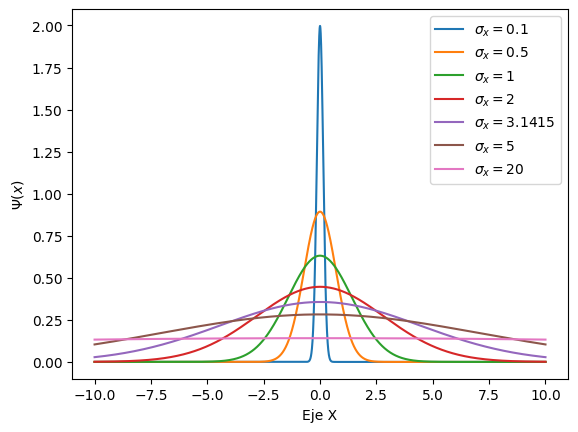

In [15]:
### CÓDIGO APARTADO 3 ############################

import matplotlib.pyplot as plt
import numpy as np

PI = 3.141592653589793  # Añade esta línea

#Ahora creo un vector de sigmas para plotearlo todo junto

sigmas= [0.1, 0.5, 1, 2, 3.1415, 5, 20]

L = 10
N = 100000
x = np.linspace(-L,L,N)

#Defino una función y un bucle para que cicle en los sigmas

def func(x, sigma):
    a = (sigma**2*PI*2)**(-1/4)
    return a*np.exp(-1/4*x**2/sigma**(2))

for sigma in sigmas:
    y= func(x, sigma)
    plt.plot(x, y, label =fr"$\sigma_x = {sigma}$")

#Le añado leyenda y los ejes

plt.xlabel("Eje X")
plt.ylabel(r"$\Psi(x)$")
plt.legend()
plt.show()

### Ejercicio 2:

Considere un pozo de potencial de barrera finita de profundidad $2.5\,\text{eV}$ y anchura $L = 4\,\text{nm}$, calcula los cinco primeros niveles de energía $(E_i)$ permitidos y las funciones de onda asociadas. Representar las funciones de onda asociadas a cada $E_i$.

**Nota:** Suponga $V_{\min} = 0\,\text{eV}$ y $V_{\max} = +2.5\,\text{eV}$.



Resolvamos este ejercicio analíticamente

Tenemos un pozo de longitud L y de valle 0 voltios y de pico 2.5 eV, a este último valor le llamaremos V.

$$
V(x)=
\begin{cases}
V & \text{si } x < -\dfrac{L}{2} \\
0 & \text{si } -\dfrac{L}{2} < x < \dfrac{L}{2} \\
V & \text{si } x > \dfrac{L}{2}
\end{cases}
$$


Esto es un pozo simétrico por lo que podemos separar las soluciones en pares e impares.

Resolvemos la ecuación de Schrödinger independiente del tiempo para definir las variables. Queremos los estados ligados, pues entonces la energía E debe ser menor que la magnitud del pozo V.

$$
\left(-\frac{\hbar^2}{2m}\nabla^2 + V\right)\psi = E\psi
$$

Reordenamos y agrupamos

$$
\frac{\hbar^2}{2m}\nabla^2 \psi = (V - E)\psi
$$

Tenemos finalmente la ecuación

$$
\nabla^2 \psi = \frac{2m}{\hbar^2}(V-E)\psi
$$

Entonces tendremos dentro del pozo V=0, pues llamamos 

$$
k_0 = \sqrt{\frac{2mE}{\hbar^2}}
$$

Y fuera del pozo (V ya no es 0), pues llamamos


$$
k = \sqrt{\frac{2m}{\hbar^2}(V-E)}
$$

Estas variables nos darán soluciones distintas. Una compleja dentro del pozo, y otra fuera del pozo.


Vayamos ahora con las soluciones pares.

$$
\psi_+(x)= C_1
\begin{cases}
e^{k x} & x < -\dfrac{L}{2} \\
A\cos(k_0x) & -\dfrac{L}{2} < x < \dfrac{L}{2} \\
e^{-k x} & x > \dfrac{L}{2}
\end{cases}
$$

Tenemos que aplicar condiciones de continuidad en la función y en la derivada. Como la función es simétrica, solo tenemos que comprobar en un caso, por ejemplo $x=-L/2$.

$$
e^{-k L/2}=A\cos\!\left(\frac{k_0L}{2}\right)
\tag{1}
$$

Y la de la derivada:

$$
k e^{-k L/2}
=
k_0A\sin\!\left(\frac{k_0L}{2}\right)
\tag{2}
$$

Y si hacemos (2) entre (1) tenemos los valores posibles para k y k_0, sabiendo que están relacionados por V.

$$
k_0\tan\!\left(\frac{k_0L}{2}\right)=k
$$

Y viendo la forma de k y de $k_0$  podemos escribir k de la siguiente manera:

$$
k= \sqrt{\frac{2mV}{\hbar^2}-k_0^2}
$$

También podemos multiplicar por el factor $L/2$ y llamar $b^2 = \frac{mVL^2}{2\hbar^2}$. Si ahora llamamos $k_0L/2 = y$, nos queda la ecuación

$$
tan(y) =\frac{\sqrt{b^2-y^2}}{y}
$$

La tangente es periódica, por lo que tendremos infinitas soluciones por su parte. Sin embargo, sabemos que la raíz debe ser real pues de no serlo, daría valores complejos para la energía. Por tanto el valor máximo que puede alcanzar $y^2$ es $b^2$.

Calculamos $\sqrt{b^2}$, que es el máximo valor de y. IMPORTANTE, aquí he asumido que es un electrón la partícula del pozo.

$$
\sqrt{b^2} = \sqrt{\frac{mVL^2}{2\hbar^2}}=\sqrt{\frac{m_e c^2 L^2 V}{2\cdot 2 \hbar^2 c^2}} = \sqrt{\frac{0.511 MeV \cdot (4\cdot 10^6)^2 fm^2 \cdot 2.5 \cdot 10^{-6} MeV}{4 \cdot 197.3 MeV^2 fm^2}} = 11.457
$$

Este número está entre $7\pi/2$ y $4\pi$. La tangente tiene valores positivos entre 0 y $pi/2$ y como es periódica en un factor de $\pi$ tendrá un total de 4 soluciones totales: entre (0, $\pi/2$), ($\pi$, $3\pi/2$), ($2\pi$, $5\pi/2$), ($3\pi$, $7\pi/2$). La solución de ($4\pi$, $9\pi$/2) ya no se alcanza.

Vayamos ahora a las soluciones impares. Ahora iré más rápido porque es totalmente análogo al proceso anterior.

Tenemos una función de onda impar, tal que:
$$
\psi_-(x)= C_2
\begin{cases}
e^{k x} & x < -\dfrac{L}{2} \\[6pt]
B\sin(k_0x) & -\dfrac{L}{2} < x < \dfrac{L}{2} \\[6pt]
-\,e^{-k x} & x > \dfrac{L}{2}
\end{cases}
$$

Aplicando condiciones de continuidad en la función y en la derivada obtenemos

$$
e^{-k L/2} = -B\sin\!\left(\frac{k_0L}{2}\right)
\tag{1}
$$

$$
k e^{-k L/2}
=
k_0B\cos\!\left(\frac{k_0L}{2}\right)
\tag{2}
$$

Si dividimos (1) entre (2), obtenemos finalmente

$$
tan(y) = \frac{-y}{\sqrt{b^2-y^2}}
$$

De nuevo está acotado por nuestro valor de b=11.457, pero esta vez tiene que tomar valores negativos la tangente, que lo hace desde $-\pi/2$ a 0 y con periodicidad pi. Por tanto también tenemos 4 soluciones, siendo la última entre $7/2\pi$ y $4\pi$.


Veamos esto mejor en el siguiente plot.

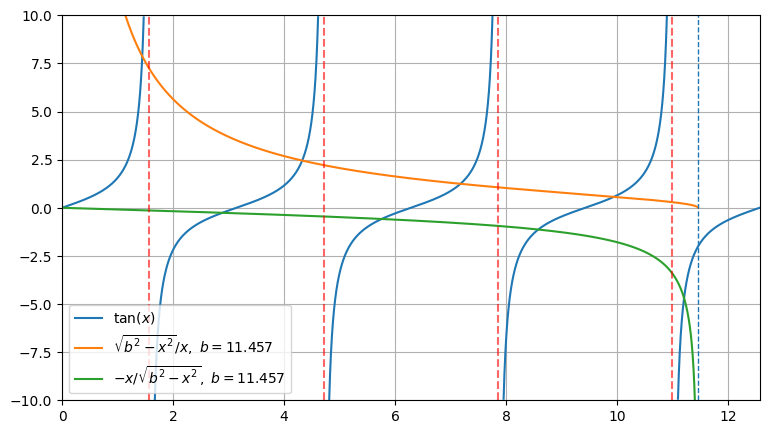

In [16]:
### PLOT DE LA TANGENTE Y LAS FUNCIONES QUE TIENE QUE SER IGUAL ############

import numpy as np
import matplotlib.pyplot as plt

#Parámetro adimensional b definido anteriormente
b= 11.457
precision = 0.001

# Nos cogemos solamente la x positiva
x_tan = np.linspace(precision ,4*np.pi, 10000) #Es periódica, pues lo hago así, hasta 4pi que es la última solución.
x_b = np.linspace(precision , b - precision, 10000)

#He tenido que cogerme un error de precisión para no dividir por 0 en las funciones, y por eso también el b-precisión. De ser positivo se pasa y da complejo y si es b solo vuelve a dar error.

#Definimos las 3 curvas: la tangente, y ambas funciones con la raíz.

y_1 = np.tan(x_tan)
y_2 = np.sqrt(b**2-x_b**2)/x_b
y_3 = -x_b/np.sqrt(b**2-x_b**2)

#Para mejora visual, pongo que si el valor de la tangente se sale pues no lo plotee, porque sino me dan lineas verticales y la tangente no hace so.

y_1[np.abs(y_1) > 10] = np.nan

#Ploteo las curvas en la misma figura.

plt.figure(figsize=(9,5))
plt.plot(x_tan, y_1, label=r'$\tan(x)$')
plt.plot(x_b,   y_2, label=rf'$\sqrt{{b^2-x^2}}/x,\ b={b}$')
plt.plot(x_b,   y_3, label=rf'$-x/\sqrt{{b^2-x^2}},\ b={b}$')

#Ajusto la función para que se vea bien

plt.ylim(-10, 10)   #He puesto esto poco a poco para que se vean todas las soluciones    
plt.xlim(0, max(4*np.pi, b))
plt.axvline(b, linestyle='--', linewidth=1)  #marca x=b (asíntota de las 2 últimas)

#Y pongo las asíntotas de la tangente que antes he quitado manualmente

n_max = int(4*np.pi/np.pi)
for n in range(-1, n_max):
    x_asym = np.pi/2 + n*np.pi
    if x_asym > 0 and x_asym < 4*np.pi:
        plt.axvline(x_asym, linestyle="--", color="red", alpha=0.6)

plt.legend()
plt.grid(True)
plt.show()


Con esto ya podemos ver que hay 4 soluciones impares y 4 pares. Ahora quiero yo quedarme con las 5 primeras energías pero para ello necesito saber los valores de k de cada solución.

Para ello haré un código que calcule el punto de corte en cada función. Como esto ya es mucho tiempo, usaré un código hecho con copilot poco a poco.

Tendré que restar las funciones a la tangente y ver donde la función se hace 0. 

In [17]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# Parámetros
b = 11.457
precision = 0.001

# Función 1: tan(x) - sqrt(b^2 - x^2)/x = 0 (soluciones pares)
def equation_par(x):
    if x <= 0 or x >= b:
        return np.inf
    return np.tan(x) - np.sqrt(b**2 - x**2) / x

# Función 2: tan(x) + x/sqrt(b^2 - x^2) = 0 (soluciones impares)
def equation_impar(x):
    if x <= 0 or x >= b:
        return np.inf
    return np.tan(x) + x / np.sqrt(b**2 - x**2)

# Encontrar soluciones pares
soluciones_pares = []
for n in range(4):
    x_inicio = n * np.pi + precision
    x_fin = (n + 0.5) * np.pi - precision
    if x_fin <= b:
        try:
            sol = fsolve(equation_par, (x_inicio + x_fin) / 2)[0]
            if precision < sol < b and abs(equation_par(sol)) < 1e-4:
                soluciones_pares.append(sol)
        except:
            pass

# Encontrar soluciones impares
soluciones_impares = []
for n in range(4):  
    x_inicio = (n + 0.5) * np.pi + precision
    x_fin = (n + 1) * np.pi - precision
    if x_inicio < b:
        try:
            sol = fsolve(equation_impar, (x_inicio + min(x_fin, b-precision)) / 2)[0]
            if precision < sol < b and abs(equation_impar(sol)) < 1e-4:
                # Evitar duplicados
                if not any(abs(sol - s) < 0.01 for s in soluciones_impares):
                    soluciones_impares.append(sol)
        except:
            pass

# Combinar y ordenar todas las soluciones
todas_soluciones = sorted(soluciones_pares + soluciones_impares)

print("Soluciones pares:")
print(np.array(soluciones_pares))
print("\nSoluciones impares:")
print(np.array(soluciones_impares))
print("\nTodas las soluciones ordenadas:")
print(np.array(todas_soluciones))
print(f"\nLas 5 primeras soluciones: {np.array(todas_soluciones[:5])}")

Soluciones pares:
[1.44438948 4.32527012 7.17701604 9.94445311]

Soluciones impares:
[ 2.88687254  5.75673818  8.57858333 11.20549338]

Todas las soluciones ordenadas:
[ 1.44438948  2.88687254  4.32527012  5.75673818  7.17701604  8.57858333
  9.94445311 11.20549338]

Las 5 primeras soluciones: [1.44438948 2.88687254 4.32527012 5.75673818 7.17701604]


In [18]:
### COMPROBAMOS QUE ESTÁN LAS SOLUCIONES ####
print(np.array(todas_soluciones))



[ 1.44438948  2.88687254  4.32527012  5.75673818  7.17701604  8.57858333
  9.94445311 11.20549338]


Ya sabemos que tenemos entonces 3 soluciones pares y 2 soluciones impares. Lo único que nos falta es normalizar la función.

Al igual que en el ejercicio 1, la probabilidad de hallar al electrón en todo el espacio debe ser uno.


Empecemos con las pares. Recordemos la función de onda:

$$
\psi_+(x)= C_1
\begin{cases}
e^{k x} & x < -\dfrac{L}{2} \\
A\cos(k_0x) & -\dfrac{L}{2} < x < \dfrac{L}{2} \\
e^{-k x} & x > \dfrac{L}{2}
\end{cases}
$$

Haciendo uso de continuidad podemos saber que $e^{-kL/2} = Acos(k_0L/2)$. Si multiplicamos por el conjugado de esa ecuación a cada lado nos queda $e^{-Lk} = |A|^2\cos^2(k_0L/2)$, cosa que usaré más adelante.

Podemos usar que es par la función.

$$
\int_\infty^\infty \bra{\psi_+}\ket{\psi_+} dx = 1 = 2\int_0^\infty \bra{\psi_+}\ket{\psi_+} dx
$$

$$
2\int_0^\infty |\psi_+|^2 dx = 2|C_1|^2 \left[ \int_0^{L/2}|A|^2cos^2(k_0x) dx + \int_{L/2}^{\infty} e^{-2kx} dx\right] =
$$

$$
= 2|C_1|^2 \left[ |A|^2\cdot 1/(4k_0) (Lk_0 + sin(Lk_0)) + \frac{e^{-Lk}}{2k}\right] = 1
$$

Despejando el valor de $C_1$ y poniendo el valor de |A|^2 de antes, obtenemos el resultado de:

$$
|C_1|^2 = \frac{e^{kL}}{2\left[\frac{Lk_o + sin(L/k_0)}{4k_0cos^2(k_0L/2)} + \frac{1}{2k} \right]}
$$

Ahora lo dejamos todo en función del parámetro k_0, que son las soluciones que tenemos previamente calculadas. Usamos que $k = \sqrt{\frac{2mV}{\hbar^2}-k_0^2}$

$$
|C_1|^2 =
\frac{
\exp\!\left(L\sqrt{\frac{2mV}{\hbar^2}-k_0^2}\right)
}{
2\left[
\frac{Lk_0+\sin(Lk_0)}{4k_0\cos^2\!\left(\frac{k_0L}{2}\right)}
+
\frac{1}{2\sqrt{\frac{2mV}{\hbar^2}-k_0^2}}
\right]
}
$$



Seguimos con la funciones impares, recordemos su forma y demos directamente su resultado

$$
\psi_-(x)= C_2
\begin{cases}
e^{k x} & x < -\dfrac{L}{2} \\[6pt]
B\sin(k_0x) & -\dfrac{L}{2} < x < \dfrac{L}{2} \\[6pt]
-\,e^{-k x} & x > \dfrac{L}{2}
\end{cases}
$$

Y dicha constante de normalización se puede escribir como:

$$
|C_2|^2=
\frac{\exp\!\left(L\sqrt{\frac{2mV}{\hbar^2}-k_0^2}\right)}{2\left[\frac{k_0L-\sin(k_0L)}{4k_0\sin^2\!\left(\frac{k_0L}{2}\right)} + \frac{1}{2\sqrt{\frac{2mV}{\hbar^2}-k_0^2}}
\right]}
$$


Calculemos ahora dichas constantes de normalización.

Para ello recuperamos los vectores de antes

In [19]:
### SACAR LAS CONSTANTES DE NORMALIZACIÓN C_1, C_2 Y A,B #######################


#Defino el pozo en fm*MeV

L = 4000000  #fm
V = 0.0000025  #MeV

m = 0.2555 #MeV
hbar = 197.327 #Mev*fm


#Primero sacamos las constantes C_1 y C_2

#Transformamos los arrays de k_0*L/2 a valores de k_0

k0_par = np.array(soluciones_pares)*2/L
k0_impar = np.array(soluciones_impares)*2/L

#print(k0_par)
#print(k0_impar)

#Defino una función que sea sacar el valor de C_1



def fun_C1(k0, V, L, m, hbar):
    
    raiz = np.sqrt(2*m*V/hbar**2 - k0**2)
    
    numerador = np.exp(L * raiz)
    
    termino1 = (L*k0 + np.sin(L*k0)) / (4 * k0 * np.cos(k0*L/2)**2)
    termino2 = 1 / (2 * raiz)
    
    denominador = 2 * (termino1 + termino2)
    
    C1_sq = numerador / denominador
    
    return np.sqrt(C1_sq)  #Te devuelve directamente C_1

#Lo mismo para C2

def fun_C2(k0, V, L, m, hbar):
    
    raiz = np.sqrt(2*m*V/hbar**2 - k0**2)
    
    numerador = np.exp(L * raiz)
    
    termino1 = (k0*L - np.sin(k0*L)) / (4 * k0 * np.sin(k0*L/2)**2)
    termino2 = 1 / (2 * raiz)
    
    denominador = 2 * (termino1 + termino2)
    
    C2_sq = numerador / denominador
    
    return np.sqrt(C2_sq)

#Ahora para cada array 

C1_array = fun_C1(k0_par, V, L, m, hbar)
C2_array = fun_C2(k0_impar, V, L, m, hbar)

print(C1_array)
print(C2_array)



#Ahora hago exactamente lo mismo para A y B

def fun_A(k0, V, L, m, hbar):
    aux = 2*m*V/(hbar**2) - k0**2
    aux = np.maximum(aux, 0.0)
    k = np.sqrt(aux)

    return np.exp(-k*L/2) / np.cos(k0*L/2)


def fun_B(k0, V, L, m, hbar):
    aux = 2*m*V/(hbar**2) - k0**2
    aux = np.maximum(aux, 0.0)
    k = np.sqrt(aux)

    return np.exp(-k*L/2) / np.sin(k0*L/2)


A_array = fun_A(k0_par, V, L, m, hbar)
B_array = fun_B(k0_impar, V, L, m, hbar)

print(A_array)
print(B_array)


[ 7.36642106 10.32281419  3.17009299  0.16698224]
[1.11352146e+01 6.77754346e+00 9.86823440e-01 6.28027403e-03]
[ 9.20273678e-05 -6.54827195e-05  2.11525986e-04 -3.90520965e-03]
[ 6.08183414e-05 -9.94323647e-05  6.73565911e-04 -9.44893811e-02]


Estos son valores muy raros. Voy rápidamente a comprobar que la probabilidad de encontrar a la partícula sigue siendo de la unidad.

Para ello usando la IA creo un programa solo para comprobar esto.

In [20]:
### COMPROBACION DE LA INTEGRAL UNITARIA ##################

import numpy as np
from scipy.integrate import quad

def check_par(C1, k0, V, L, m, hbar):
    # Todo en fm (L, x) y fm^-1 (k0, k)
    k = np.sqrt(np.maximum(2*m*V/hbar**2 - k0**2, 0.0))
    z = k0*L/2
    A = np.exp(-k*L/2)/np.cos(z)

    # integrales por trozos (evita líos con inf)
    x_max = L/2 + 50.0/max(k, 1e-15)

    I_left,  _ = quad(lambda x: (C1*np.exp(k*x))**2, -x_max, -L/2)
    I_mid,   _ = quad(lambda x: (C1*A*np.cos(k0*x))**2, -L/2, L/2)
    I_right, _ = quad(lambda x: (C1*np.exp(-k*x))**2,  L/2, x_max)

    return I_left + I_mid + I_right


def check_impar(C2, k0, V, L, m, hbar):
    k = np.sqrt(np.maximum(2*m*V/hbar**2 - k0**2, 0.0))
    z = k0*L/2
    B = np.exp(-k*L/2)/np.sin(z)

    x_max = L/2 + 50.0/max(k, 1e-15)

    I_left,  _ = quad(lambda x: (C2*np.exp(k*x))**2, -x_max, -L/2)
    I_mid,   _ = quad(lambda x: (C2*B*np.sin(k0*x))**2, -L/2, L/2)
    I_right, _ = quad(lambda x: (C2*np.exp(-k*x))**2,  L/2, x_max)

    return I_left + I_mid + I_right



for i in range(len(k0_par)):
    print(i, check_par(C1_array[i], k0_par[i], V, L, m, hbar))

for i in range(len(k0_impar)):
    print(i, check_impar(C2_array[i], k0_impar[i], V, L, m, hbar))

0 1.0
1 1.0000000000000002
2 0.9999999999999999
3 1.0000000000000002
0 1.0
1 1.0000000000000002
2 1.0
3 1.0


Tras una comprobación ya tenemos las constantes de normalización y las energías. Estamos totalmente preparados para poder representar dichas funciones de onda.



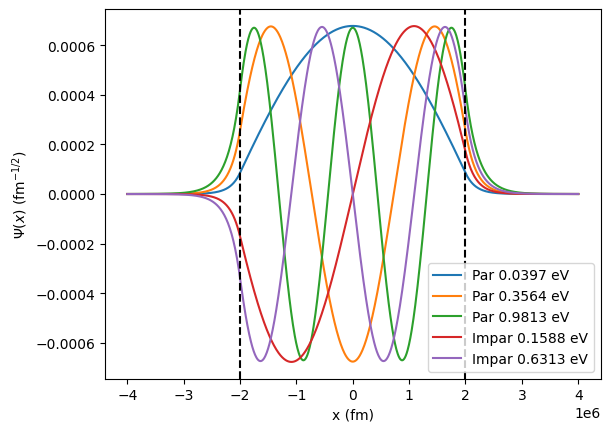

In [21]:
### REPRESENTAR LAS FUNCIONES DE ONDA ########################

x = np.linspace(-L, L, 1000) #Para que no solo sea el pozo, sino más. Pero la exponencial no penetrará mucho, así que este intervalo está bien

#Tengo que crear un array con los k de pares e impares, ya que solo tengo el de k0

k_par = np.array(np.sqrt((2*m*V/(hbar**2)-k0_par**2)))
k_impar = np.array(np.sqrt((2*m*V/(hbar**2)-k0_impar**2)))

#Ya que estoy, calculo las energías asociadas. 

E_par = np.array(k0_par**2*hbar**2/(2*m))
E_impar = np.array(k0_impar**2*hbar**2/(2*m))


#Creo la función para los estados pares

for i in range(3):
    #Inicializo a 0 y tantos ceros como haya en x, asi solo modifico x
    psi = np.zeros_like(x)
    for j in range(len(x)):
        if x[j] < -L/2:
            psi[j] = C1_array[i]*np.exp(k_par[i]*x[j])
        elif -L/2 <= x[j] <= L/2:
            psi[j] = C1_array[i]*A_array[i]*np.cos(k0_par[i]*x[j])
        else:
            psi[j] = C1_array[i]*np.exp(-k_par[i]*x[j])
    plt.plot(x, psi, label=f"Par {E_par[i]*10**6:.4f} eV")


#Lo mismo para los impares:

for i in range(2):
    #Inicializo a 0 y tantos ceros como haya en x, asi solo modifico x
    psi = np.zeros_like(x)
    for j in range(len(x)):
        if x[j] < -L/2:
            psi[j] = -C2_array[i]*np.exp(k_impar[i]*x[j])
        elif -L/2 <= x[j] <= L/2:
            psi[j] = C2_array[i]*B_array[i]*np.sin(k0_impar[i]*x[j])
        else:
            psi[j] = C2_array[i]*np.exp(-k_impar[i]*x[j])
    plt.plot(x, psi, label=f"Impar {E_impar[i]*10**6:.4f} eV")
    
    

#Puedo también plotear donde está el pozo
plt.axvline(-L/2, linestyle="--", color="black")
plt.axvline(L/2, linestyle="--", color="black")

plt.xlabel("x (fm)")
plt.ylabel(r"$\Psi(x)$ (fm$^{-1/2}$)")
plt.legend()
plt.show()



### Ejercicio 3

Considere una barrera de potencial de altura $V_0$ (eV) y anchura $L$ (nm) y tome el origen de energías en $0\,\text{eV}$. Un electrón incide desde la izquierda con energía $E$. Haciendo uso de los resultados analíticos, calcule y represente el coeficiente de reflexión $(R)$ y transmisión $(T)$ en las siguientes situaciones:


Ahora tenemos un pozo que en x=0 hasta x=L vale V_0 >0 eV. El problema es análogo, la dificultad está en calcular los coeficientes de transmisión T y reflexión R.

Afortunadamente usando los apuntes de Daniel Rodriguez Rubiales profesor de Cuántica, tenemos este resultado para los casos en los que la energía sea mayor que el potencial y podemos deducir si es menor, ya que solo cambia la fase, es decir, un seno se vuelve seno hiperbólico y viceversa.

Uso la misma notación, k será el valor donde el potencial sea no nulo y k_0 será donde sí sea nulo.

**Caso 1: E < V**
$$
T = \frac{1}{1 + \frac{V_0^2}{4E(V_0-E)sinh^2(kL)}}
$$

Como el coeficiente de reflexión R = 1-T, pues con calcular T nos sirve

**Caso 2: E > V**
$$
T = \frac{1}{1 + \frac{V_0^2}{4E(E-V_0)sin^2(kL)}}
$$

Nótese que también he cambiado E y V_0 de lugar, para que el resultado siempre de positivo.


##### Apartado 1: En función de la energía del electrón cuando $V_0 = 1\,\text{eV}$ y $L = 4\,\text{nm}$. Considere que la energía del electrón varía desde $E = 0\,\text{eV}$ hasta $E = 2\,\text{eV}$.

Tenemos un potencial finito y fijo, variando la energía. 

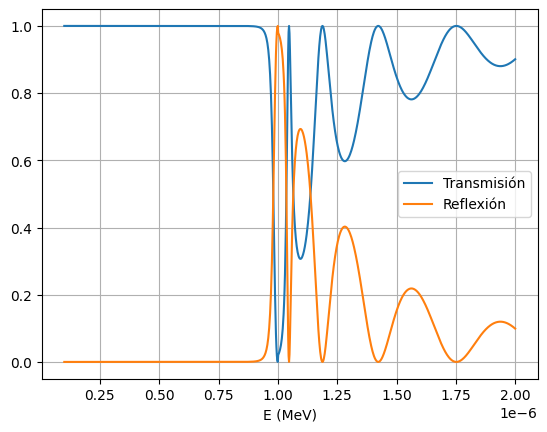

In [22]:
### PROGRAMA PARA PLOTEAR T Y R EN FUNCIÓN DE E ######################33


hbar= 197.327 #MeV*fem
m = 0.2555 #MeV
Emax = 2*10**-6 #MeV
L = 4000000 #fm
V = 1*10**-6 #MeV

E = np.linspace(0.0000001, Emax, 1000)

T = np.zeros_like(E)
R = np.zeros_like(E)

#Defino las T para si es E<V (menor) o E>V (mayor)

def func_Tmenor(E, V, L):
    k = np.sqrt(2*m*(V-E)/(hbar**2))
    T = 1/(1+V**2/(4*E*(V-E)*np.sinh(k*L)**2))
    return T

def func_Tmayor(E, V, L):
    k = np.sqrt(2*m*(E-V)) / hbar
    T = 1 / (1 + (V**2 / (4*E*(E-V))) * np.sin(k*L)**2)
    return T

#Calculo dichas T y R

for i in range(len(E)):
    if E[i] < V:
        T[i] = func_Tmenor(E[i], V, L)
    elif E[i] > V:
        T[i] = func_Tmayor(E[i], V, L)
    else:
        T[i] = 1   #Trato aparte el caso E=V
    R[i] = 1-T[i]
    
    
#Las ploteo

plt.plot(E, T, label= "Transmisión")
plt.plot(E, R, label="Reflexión")

plt.xlabel("E (MeV)")
plt.legend()
plt.grid()
plt.show()



##### Apartado 2: En función de $V_0$ cuando $L = 2\,\text{nm}$ y la energía del electrón toma los valores $E = 0.2\,\text{eV}$, $0.5\,\text{eV}$ y $0.9\,\text{eV}$.

Es prácticamente lo mismo, ahora fijamos energía y vamos moviendo el potencial. Solo hay que cambiar que es el potencial el nuevo eje X y que hay 3 valores de energía, por lo que haremos un linspace con eso o copiaré 3 veces, lo que sea más rápido.

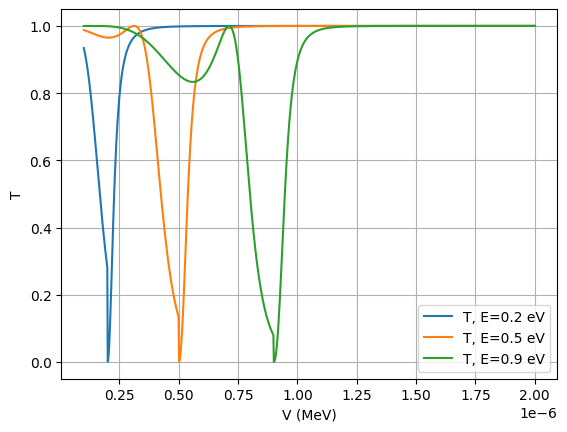

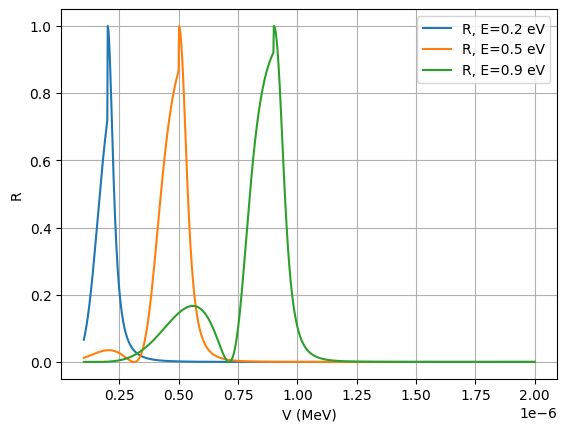

In [23]:
### PROGRAMA PARA PLOTEAR T Y R EN FUNCIÓN DE V ######################


hbar= 197.327 #MeV*fem
m = 0.2555 #MeV
L = 2000000 #fm
Vmax = 2 * 10**(-6) #MeV

V = np.linspace(0.0000001, Vmax, 1000)

T1 = np.zeros_like(V)
T2 = np.zeros_like(V)
T3 = np.zeros_like(V)
R1 = np.zeros_like(V)
R2 = np.zeros_like(V)
R3 = np.zeros_like(V)

E1 = 0.2 * 10**(-6) #MeV
E2 = 0.5 * 10**(-6) #MeV
E3 = 0.9 * 10**(-6) #MeV

def func_Tmenor(E, V, L):
    k = np.sqrt(2*m*(V-E)/(hbar**2))
    T = 1/(1+V**2/(4*E*(V-E)*np.sinh(k*L)**2))
    return T

def func_Tmayor(E, V, L):
    k = np.sqrt(2*m*(E-V)) / hbar
    T = 1 / (1 + (V**2 / (4*E*(E-V))) * np.sin(k*L)**2)
    return T


#Calculamos para los 3 casos


for i in range(len(V)):
    if E1 < V[i]:
        T1[i] = func_Tmenor(E1, V[i], L)
    elif E1 > V[i]:
        T1[i] = func_Tmayor(E1, V[i], L)
    else:
        T1[i] = 1  
    R1[i] = 1-T1[i]


for i in range(len(V)):
    if E2 < V[i]:
        T2[i] = func_Tmenor(E2, V[i], L)
    elif E2 > V[i]:
        T2[i] = func_Tmayor(E2, V[i], L)
    else:
        T2[i] = 1  
    R2[i] = 1-T2[i]


for i in range(len(V)):
    if E3 < V[i]:
        T3[i] = func_Tmenor(E3, V[i], L)
    elif E3 > V[i]:
        T3[i] = func_Tmayor(E3, V[i], L)
    else:
        T3[i] = 1  
    R3[i] = 1-T3[i]

#Ploteamos

plt.figure()
plt.plot(V, T1, label="T, E=0.2 eV")
plt.plot(V, T2, label="T, E=0.5 eV")
plt.plot(V, T3, label="T, E=0.9 eV")
plt.xlabel("V (MeV)")
plt.ylabel("T")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(V, R1, label="R, E=0.2 eV")
plt.plot(V, R2, label="R, E=0.5 eV")
plt.plot(V, R3, label="R, E=0.9 eV")
plt.xlabel("V (MeV)")
plt.ylabel("R")
plt.legend()
plt.grid()
plt.show()